In [8]:
from qiskit import QuantumCircuit, transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram

In [9]:
# The aim of the assignment is to simulate the BB84 key distribution protocol.

# This notebook is for a simulation of the protocol with an attacker, to demonstrate that the attacker can be detected.

In [10]:
backend = BasicSimulator()

def measure_bit(circuit):
    compiled = transpile(circuit, backend)
    job = backend.run(compiled, shots=1)
    result = job.result()
    counts = result.get_counts(compiled)
    return int(list(counts.keys())[0])

def random_bits(n):
    bits = []
    for i in range(n):
        qc = QuantumCircuit(1, 1)
        qc.h(0)
        qc.measure(0, 0)
        bits = bits + [measure_bit(qc)]
    return bits

def prepare_bb84_qubit(bit, basis):
    qc = QuantumCircuit(1, 1)
    if bit == 1:
        qc.x(0)
    if basis == 1:
        qc.h(0)
    return qc

def measure_bb84_qubit(bit, send_basis, receive_basis):
    qc = prepare_bb84_qubit(bit, send_basis)
    if receive_basis == 1:
        qc.h(0)
    qc.measure(0, 0)
    return measure_bit(qc)

def basis_name(basis):
    if basis == 0:
        return "Z"
    else:
        return "X"

def bits_to_string(bits):
    return "".join([str(bit) for bit in bits])

def print_attacker_report(n, threshold, alice_bits, alice_bases, eve_bases, eve_results, bob_bases, bob_results, matching_positions, alice_key, bob_key, errors, error_rate, attack_detected):
    print("BB84 with intercept-resend attacker")
    print("----------------------------------")
    print("Basis names: Z = computational, X = diagonal")
    print("Number of qubits sent:", n)
    print("Matching bases:", len(matching_positions))
    print("Sifted key length:", len(alice_key))
    print("Alice sifted key:", bits_to_string(alice_key))
    print("Bob sifted key:  ", bits_to_string(bob_key))
    print("Errors in sifted key:", errors)
    print(f"Error rate: {100 * error_rate:.2f}%")
    print(f"Detection threshold: {100 * threshold:.2f}%")
    print("Attack detected:", attack_detected)
    print()
    print("Kept positions only")
    print()
    print("Position | A bit | A basis | E basis | E result | B basis | B result | Match")
    print("-------------------------------------------------------------------------------")
    for i in matching_positions:
        match = "Yes" if alice_bits[i] == bob_results[i] else "No"
        print(f"{i:>8} | {alice_bits[i]:>5} | {basis_name(alice_bases[i]):>7} | {basis_name(eve_bases[i]):>7} | {eve_results[i]:>8} | {basis_name(bob_bases[i]):>7} | {bob_results[i]:>8} | {match}")

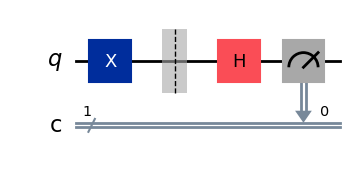

In [11]:
# A single round of BB84 with an attacker
# In this example Alice chooses bit 1 in the computational basis,
# and Eve measures in the diagonal basis.

alice_bit = 1
alice_basis = 0
eve_basis = 1

eve_intercept = QuantumCircuit(1,1)

# Alice prepares the qubit.
if alice_bit == 1:
    eve_intercept.x(0)
if alice_basis == 1:
    eve_intercept.h(0)

eve_intercept.barrier()

# Eve chooses the basis in which she will measure the qubit.
if eve_basis == 1:
    eve_intercept.h(0)

# Eve measures the intercepted qubit.
eve_intercept.measure([0],[0])
eve_intercept.draw("mpl")

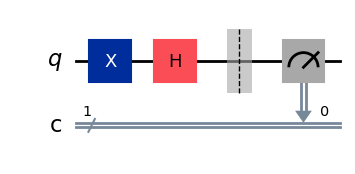

In [12]:
# After Eve measures, she resends a new qubit to Bob.
# Suppose Eve measured 1 in the previous circuit.

eve_result = 1
eve_basis = 1
bob_basis = 0

eve_resend = QuantumCircuit(1,1)

# Eve prepares a new qubit from her measurement result and the basis she used.
if eve_result == 1:
    eve_resend.x(0)
if eve_basis == 1:
    eve_resend.h(0)

eve_resend.barrier()

# Bob now measures the resent qubit in his own basis.
if bob_basis == 1:
    eve_resend.h(0)

eve_resend.measure([0],[0])
eve_resend.draw("mpl")

BB84 with intercept-resend attacker
----------------------------------
Basis names: Z = computational, X = diagonal
Number of qubits sent: 100
Matching bases: 49
Sifted key length: 49
Alice sifted key: 1001000101110011000101101100110111110001001101010
Bob sifted key:   0111010111100111101101111110111001010010011111010
Errors in sifted key: 19
Error rate: 38.78%
Detection threshold: 12.00%
Attack detected: True

Kept positions only

Position | A bit | A basis | E basis | E result | B basis | B result | Match
-------------------------------------------------------------------------------
       0 |     1 |       X |       Z |        1 |       X |        0 | No
       1 |     0 |       Z |       X |        0 |       Z |        1 | No
       3 |     0 |       Z |       X |        1 |       Z |        1 | No
       5 |     1 |       Z |       Z |        1 |       Z |        1 | Yes
      10 |     0 |       X |       X |        0 |       X |        0 | Yes
      11 |     0 |       Z |       

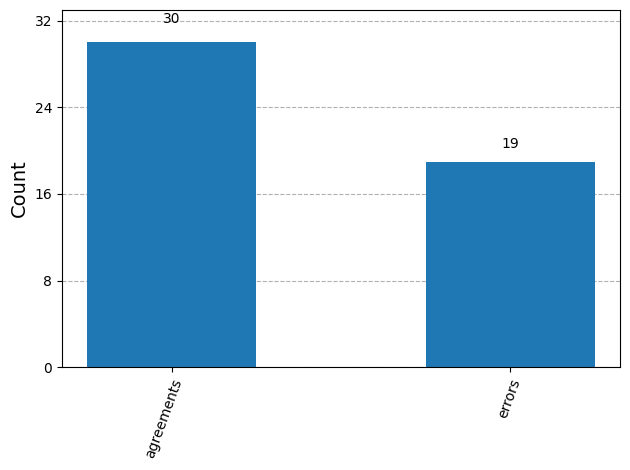

In [13]:
# BB84 with a simple intercept-resend attacker

n = 100
threshold = 0.12

# Alice chooses random bits and random bases.
alice_bits = random_bits(n)
alice_bases = random_bits(n)

# Eve intercepts every qubit, measures it in a random basis, and resends.
eve_bases = random_bits(n)
eve_results = []
for i in range(n):
    eve_results = eve_results + [measure_bb84_qubit(alice_bits[i], alice_bases[i], eve_bases[i])]

# Bob measures the resent qubits in his own random bases.
bob_bases = random_bits(n)
bob_results = []
for i in range(n):
    bob_results = bob_results + [measure_bb84_qubit(eve_results[i], eve_bases[i], bob_bases[i])]

# Alice and Bob compare bases and keep only matching positions.
matching_positions = []
for i in range(n):
    if alice_bases[i] == bob_bases[i]:
        matching_positions = matching_positions + [i]

alice_key = [alice_bits[i] for i in matching_positions]
bob_key = [bob_results[i] for i in matching_positions]

errors = 0
for i in range(len(alice_key)):
    if alice_key[i] != bob_key[i]:
        errors = errors + 1

if len(alice_key) > 0:
    error_rate = errors / len(alice_key)
else:
    error_rate = 0

attack_detected = error_rate > threshold

print_attacker_report(n, threshold, alice_bits, alice_bases, eve_bases, eve_results, bob_bases, bob_results, matching_positions, alice_key, bob_key, errors, error_rate, attack_detected)

plot_histogram({"agreements": len(alice_key) - errors, "errors": errors})